In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "README.md").is_file() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "README.md").is_file():
    raise FileNotFoundError("Run this notebook from the project directory or one of its subdirectories.")


# EXP05 — LightGBM Direct Multi-Target Regression + 5-Fold CV + Optuna + OOF

이 노트북은 `train_final_physics.csv`를 입력으로 사용하여 과거 48시간(289스텝) 시계열 통계/모멘텀 피처를 엔지니어링하고, 6개 리드타임(+3h, +6h, +9h, +12h, +18h, +24h) 각각에 대해 5-Fold LightGBM 회귀기를 학습합니다.

### 파이프라인 구성
1. **시계열 표(Tabular) 피처 엔지니어링**: 기준시각($t=0$) 값, 최근 1~6h 차분/모멘텀, 6~48h 이동평균/최대값/최소값/표준편차, 파랑 역학 지표 추출
2. **대회 지표 맞춤형 5-Fold Cross Validation**: $h_s \ge 1.5\text{m}$ 고파랑 검증 지표(`comp_rmse`)를 평가
3. **Optuna 하이퍼파라미터 최적화**
4. **Out-Of-Fold(OOF) 예측값 저장** (iTransformer와의 스태킹/블렌딩용)
5. **`test_context.parquet` 추론 및 `submission_exp05.csv` 생성**

BEST Competition Integrated RMSE (hs >= 1.5m, All 6 Leads): 0.25663 m
BEST PARAMS:
{
  "learning_rate": 0.049841862151652025,
  "num_leaves": 64,
  "max_depth": 9,
  "min_child_samples": 33,
  "subsample": 0.7910323731711344,
  "colsample_bytree": 0.7195425332274223,
  "reg_alpha": 1.3115074033277803,
  "reg_lambda": 0.0657195137220231
}

In [1]:
# ============================================================
# 0. SETUP & PACKAGES
# ============================================================
!pip -q install optuna lightgbm

from pathlib import Path
import gc
import json
import warnings

import numpy as np

# Compatibility shim for Pandas versions that still reference np.matrix.
# NumPy 2 removed np.matrix; alias it to ndarray only when it is absent.
if not hasattr(np, "matrix"):
    np.matrix = np.ndarray

import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import KFold
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
def seed_everything(seed=SEED):
    np.random.seed(seed)

seed_everything()
print("Setup Complete.")


Setup Complete.


In [2]:
# ============================================================
# 1. CONFIG
# ============================================================
DATA_PATH = Path(PROJECT_ROOT / "data" / "processed" / "train_final_physics_v3.csv")
TEST_CONTEXT_PATH = Path(PROJECT_ROOT / "data" / "raw" / "test_context.parquet")
TEST_INDEX_PATH = Path(PROJECT_ROOT / "data" / "raw" / "test_index.csv")
SUBMISSION_PATH = Path(PROJECT_ROOT / "submission" / "submission_exp05.csv")

EXP_DIR = PROJECT_ROOT / "artifacts" / "experiments" / "exp05"
EXP_DIR.mkdir(parents=True, exist_ok=True)

TIME_COL = "time"
STATION_COL = "station"

STEP_MINUTES = 10
STEPS_PER_HOUR = 6

INPUT_LEN = 289
LEAD_HOURS = [3, 6, 9, 12, 18, 24]
LEAD_STEPS = [h * STEPS_PER_HOUR for h in LEAD_HOURS]
N_SPLITS = 5

print("INPUT_LEN:", INPUT_LEN)
print("LEADS:", LEAD_HOURS)


INPUT_LEN: 289
LEADS: [3, 6, 9, 12, 18, 24]


In [3]:
# ============================================================
# 2. LOAD TRAIN DATA
# ============================================================
df = pd.read_csv(DATA_PATH, parse_dates=[TIME_COL])
df = df.sort_values([STATION_COL, TIME_COL]).reset_index(drop=True)

if "hs_original_observed" not in df.columns:
    df["hs_original_observed"] = df["hs"].notna().astype(np.int8)

print("shape:", df.shape)
print("stations:", df[STATION_COL].unique())
print("period:", df[TIME_COL].min(), "~", df[TIME_COL].max())


shape: (183600, 36)
stations: ['G-ORS' 'I-ORS' 'S-ORS']
period: 2024-01-01 00:00:00+09:00 ~ 2025-06-30 23:50:00+09:00


In [4]:
# ============================================================
# 3. TABULAR FEATURE EXTRACTION FROM 48H WINDOWS
# ============================================================
def extract_window_features(window_df):
    """289스텝(48시간) 시계열 윈도우에서 머신러닝용 통계/모멘텀 피처 추출"""
    feat = {}

    # 1. 기준시각(t=0, 윈도우 마지막 시점) 원본 물리량
    last = window_df.iloc[-1]
    for col in ["hs", "tp", "hmax", "wspd", "gust", "u_wind", "v_wind", "u_wave", "v_wave",
                "wave_steepness", "wave_energy", "effective_wind_forcing",
                "wind_wave_alignment", "wind_wave_diff", "caph", "airt", "relh"]:
        if col in window_df.columns:
            feat[f"{col}_last"] = float(last[col])

    # 2. 단기 모멘텀 및 변화율 (최근 1h=6스텝, 3h=18스텝, 6h=36스텝)
    for span, name in [(6, "1h"), (18, "3h"), (36, "6h")]:
        sub = window_df.iloc[-span:]
        feat[f"hs_diff_{name}"] = float(last["hs"] - sub["hs"].iloc[0])
        feat[f"wspd_diff_{name}"] = float(last["wspd"] - sub["wspd"].iloc[0])
        feat[f"caph_diff_{name}"] = float(last["caph"] - sub["caph"].iloc[0])
        feat[f"hs_mean_{name}"] = float(sub["hs"].mean())
        feat[f"wspd_mean_{name}"] = float(sub["wspd"].mean())

    # 3. 중장기 통계량 (최근 12h=72스텝, 24h=144스텝, 48h=289스텝)
    for span, name in [(72, "12h"), (144, "24h"), (289, "48h")]:
        sub = window_df.iloc[-span:]
        for col in ["hs", "hmax", "wspd", "gust", "effective_wind_forcing", "wave_energy"]:
            if col in window_df.columns:
                feat[f"{col}_mean_{name}"] = float(sub[col].mean())
                feat[f"{col}_max_{name}"] = float(sub[col].max())
                feat[f"{col}_std_{name}"] = float(sub[col].std())

    # 4. 파랑-바람 비율 및 동역학
    feat["hmax_hs_ratio_last"] = float(last["hmax"] / max(last["hs"], 0.01))
    feat["gust_wspd_ratio_last"] = float(last["gust"] / max(last["wspd"], 0.01))
    feat["wave_age_proxy_last"] = float((1.56 * last["tp"]) / max(last["wspd"], 0.1))

    return feat

print("Feature extraction function defined.")


Feature extraction function defined.


In [5]:
# ============================================================
# 4. BUILD TRAINING TABULAR SAMPLES (DOWN-SAMPLED STRIDE)
# ============================================================
print("Extracting training tabular samples...")
X_rows, y_rows, origin_hs_list, origin_times, station_list = [], [], [], [], []

STRIDE = 1  # 30분 간격 샘플링 (학습 속도 및 메모리 효율화)
max_lead = max(LEAD_STEPS)

for st, g in df.groupby(STATION_COL):
    g = g.sort_values(TIME_COL).reset_index(drop=True)
    dt = pd.Series(g[TIME_COL]).diff().dt.total_seconds().div(60).to_numpy()

    for end_idx in range(INPUT_LEN - 1, len(g) - max_lead, STRIDE):
        start_idx = end_idx - INPUT_LEN + 1
        if not np.all(dt[start_idx + 1:end_idx + 1] == STEP_MINUTES):
            continue

        target_idx = [end_idx + s for s in LEAD_STEPS]
        y = g.loc[target_idx, "hs"].to_numpy(dtype=np.float32)
        obs = g.loc[target_idx, "hs_original_observed"].to_numpy(dtype=np.int8)
        if not np.isfinite(y).all() or not np.all(obs == 1):
            continue

        win_df = g.iloc[start_idx:end_idx + 1]
        feats = extract_window_features(win_df)
        feats["station"] = st

        X_rows.append(feats)
        y_rows.append(y)
        origin_hs_list.append(float(g.loc[end_idx, "hs"]))
        origin_times.append(g.loc[end_idx, TIME_COL])
        station_list.append(st)

X_train_df = pd.DataFrame(X_rows)
# 원-핫 인코딩
X_train_df = pd.get_dummies(X_train_df, columns=["station"], drop_first=False)
feature_cols = [c for c in X_train_df.columns]

Y_train_arr = np.asarray(y_rows, dtype=np.float32)
origin_hs_arr = np.asarray(origin_hs_list, dtype=np.float32)

print(f"Tabular Dataset Ready: X={X_train_df.shape}, Y={Y_train_arr.shape}")
print(f"High-wave samples (hs >= 1.5m): {(origin_hs_arr >= 1.5).sum()} / {len(origin_hs_arr)}")


Extracting training tabular samples...


Tabular Dataset Ready: X=(129600, 92), Y=(129600, 6)
High-wave samples (hs >= 1.5m): 31199 / 129600


In [6]:
# ============================================================
# 5. METRICS & CUSTOM EVALUATION
# ============================================================
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def evaluate_predictions(y_true, y_pred, origin_hs):
    overall = rmse(y_true, y_pred)
    mask = origin_hs >= 1.5
    comp = rmse(y_true[mask], y_pred[mask]) if mask.sum() > 0 else np.nan
    res = {
        "overall_rmse": overall,
        "comp_rmse": comp,
        "comp_n": int(mask.sum()),
    }
    for i, h in enumerate(LEAD_HOURS):
        res[f"rmse_{h}h"] = rmse(y_true[:, i], y_pred[:, i])
        res[f"comp_rmse_{h}h"] = rmse(y_true[mask, i], y_pred[mask, i]) if mask.sum() > 0 else np.nan
    return res


In [7]:
# ============================================================
# 6. OPTUNA TUNING FOR LIGHTGBM (대회 공식 통합 RMSE 정렬 버전)
# ============================================================
import optuna

optuna.logging.set_verbosity(optuna.logging.INFO)
print("Starting Optuna Tuning with Official Competition Integrated RMSE Metric...\n")

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# 고파랑 샘플 가중치 (hs >= 1.5m -> 3.33배 집중)
sample_weights = np.where(origin_hs_arr >= 1.5, 3.33, 1.0)

def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "random_state": SEED,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 31, 127),
        "max_depth": trial.suggest_int("max_depth", 5, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 0.95),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.95),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 5.0, log=True),
        "n_estimators": 600,
        "n_jobs": -1,
        "verbose": -1,
    }

    # 5개 Fold 전체에 대한 6개 리드타임 OOF 예측 행렬 (N x 6)
    oof_val_preds = np.zeros_like(Y_train_arr)

    for lead_idx, lead_h in enumerate(LEAD_HOURS):
        y_target = Y_train_arr[:, lead_idx]

        for train_idx, val_idx in kf.split(X_train_df):
            X_tr, y_tr, w_tr = X_train_df.iloc[train_idx], y_target[train_idx], sample_weights[train_idx]
            X_va, y_va = X_train_df.iloc[val_idx], y_target[val_idx]

            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_tr, y_tr, sample_weight=w_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[lgb.early_stopping(30, verbose=False)]
            )

            oof_val_preds[val_idx, lead_idx] = model.predict(X_va)

    # 대회 공식 지표: 전체 사례의 6개 리드타임 오차를 통합한 단일 RMSE
    # (N samples x 6 leads) 전체 원소의 제곱오차 평균에 루트를 적용한다.
    official_integrated_comp_rmse = float(
        np.sqrt(np.mean((Y_train_arr - oof_val_preds) ** 2))
    )

    return official_integrated_comp_rmse

study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=SEED),
    study_name="exp05_lgbm_competition_metric"
)

study.optimize(objective, n_trials=20, gc_after_trial=True)

print("\n" + "=" * 70)
print(f"BEST Official Integrated RMSE (All Samples, All 6 Leads): {study.best_value:.5f} m")
print("BEST PARAMS:")
print(json.dumps(study.best_params, indent=2))
print("=" * 70)

with open(EXP_DIR / "best_params.json", "w", encoding="utf-8") as f:
    json.dump(study.best_params, f, indent=2)

[I 2026-08-29 04:32:09,618] A new study created in memory with name: exp05_lgbm_competition_metric


Starting Optuna Tuning with Official Competition Integrated RMSE Metric...



[I 2026-08-29 04:59:47,942] Trial 0 finished with value: 0.21662744879722595 and parameters: {'learning_rate': 0.021789307659775742, 'num_leaves': 123, 'max_depth': 9, 'min_child_samples': 68, 'subsample': 0.6546065241548528, 'colsample_bytree': 0.6545980821176709, 'reg_alpha': 0.00018747059221802545, 'reg_lambda': 1.1752647960576206}. Best is trial 0 with value: 0.21662744879722595.
[I 2026-08-29 05:10:27,335] Trial 1 finished with value: 0.3062073290348053 and parameters: {'learning_rate': 0.034902854606300035, 'num_leaves': 99, 'max_depth': 5, 'min_child_samples': 98, 'subsample': 0.8913549242801475, 'colsample_bytree': 0.6743186887373966, 'reg_alpha': 0.0007151383480402494, 'reg_lambda': 0.0007274653135669422}. Best is trial 0 with value: 0.21662744879722595.
[I 2026-08-29 05:42:37,857] Trial 2 finished with value: 0.26129332184791565 and parameters: {'learning_rate': 0.018826002986047252, 'num_leaves': 81, 'max_depth': 7, 'min_child_samples': 43, 'subsample': 0.8141485131528328, '

KeyboardInterrupt: 

### Optuna Tuning Visualization

Let's visualize the results of the Optuna hyperparameter optimization. This helps understand the search process and the importance of different parameters.

In [ ]:
import matplotlib.pyplot as plt
import optuna.visualization as opt_vis

# Plot optimization history
fig1 = opt_vis.plot_optimization_history(study)
fig1.update_layout(title='Optuna Optimization History')
fig1.show()

# Plot parameter importances
fig2 = opt_vis.plot_param_importances(study)
fig2.update_layout(title='Optuna Parameter Importances')
fig2.show()

# Plot slice (e.g., for learning_rate and num_leaves)
fig3 = opt_vis.plot_slice(study, params=['learning_rate', 'num_leaves', 'max_depth', 'min_child_samples', 'subsample', 'colsample_bytree', 'reg_alpha', 'reg_lambda'])
fig3.update_layout(title='Optuna Parameter Slice Plot')
fig3.show()

# Note: optuna.visualization generates Plotly figures, which are interactive in notebooks.

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import KFold
# optuna import is not needed here as best params are fixed
# from optuna.samplers import TPESampler # Not needed

# Define SEED for independent execution of this cell
SEED = 42

# ============================================================
# 7. 5-FOLD MULTI-TARGET TRAINING & OOF GENERATION
# ============================================================
# Using the fixed best parameters provided by the user
BEST_PARAMS = {
  "learning_rate": 0.049841862151652025,
  "num_leaves": 64,
  "max_depth": 9,
  "min_child_samples": 33,
  "subsample": 0.7910323731711344,
  "colsample_bytree": 0.7195425332274223,
  "reg_alpha": 1.3115074033277803,
  "reg_lambda": 0.0657195137220231
}

BEST_PARAMS.update({
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "random_state": SEED,
    "n_estimators": 1500,
    "n_jobs": -1,
    "verbose": 0,
})

oof_predictions = np.zeros_like(Y_train_arr)
models_by_lead = {h: [] for h in LEAD_HOURS}
# eval_results_by_lead will store a list of dictionaries for each lead_h (one dict per fold)
eval_results_by_lead = {h: [] for h in LEAD_HOURS}

print("\n===== 5-FOLD TRAINING FOR ALL 6 LEAD TIMES =====")
for lead_idx, lead_h in enumerate(LEAD_HOURS):
    print(f"\n--- Training Lead Time: +{lead_h}h (Horizon {lead_idx+1}/6) ---")
    y_target = Y_train_arr[:, lead_idx]

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_df)):
        X_tr, y_tr, w_tr = X_train_df.iloc[train_idx], y_target[train_idx], sample_weights[train_idx]
        X_va, y_va, o_hs_va = X_train_df.iloc[val_idx], y_target[val_idx], origin_hs_arr[val_idx]

        model = lgb.LGBMRegressor(**BEST_PARAMS)

        model.fit(
            X_tr, y_tr, sample_weight=w_tr,
            eval_set=[(X_va, y_va)],
            eval_metric='rmse', # Explicitly set eval_metric to capture
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        # Store the populated dictionary for this fold
        # Retrieve results from the fitted model. evals_result_ is populated if eval_set is provided.
        current_fold_eval_results = model.evals_result_
        eval_results_by_lead[lead_h].append(current_fold_eval_results)

        val_pred = model.predict(X_va)
        oof_predictions[val_idx, lead_idx] = val_pred
        models_by_lead[lead_h].append(model)

    fold_comp = rmse(y_target[origin_hs_arr >= 1.5], oof_predictions[origin_hs_arr >= 1.5, lead_idx])
    print(f"Lead +{lead_h}h OOF comp_rmse: {fold_comp:.5f}")

# 전체 OOF 종합 평가
final_metrics = evaluate_predictions(Y_train_arr, oof_predictions, origin_hs_arr)
print("\n================================================")
print("EXP05 OVERALL OOF EVALUATION METRICS")
print("================================================")
display(pd.Series(final_metrics).to_frame("value"))

# OOF 파일 저장 (앙상블용)
oof_df = pd.DataFrame(oof_predictions, columns=[f"pred_{h}h" for h in LEAD_HOURS])
oof_df["origin_hs"] = origin_hs_arr
oof_df["origin_time"] = origin_times
oof_df.to_csv(PROJECT_ROOT / "oof" / PROJECT_ROOT / "oof" / "oof_exp05.csv", index=False)
pd.DataFrame([final_metrics]).to_csv(EXP_DIR / "final_metrics.csv", index=False)


NameError: name 'Y_train_arr' is not defined


Plotting RMSE progression for Lead Time +6h across folds...


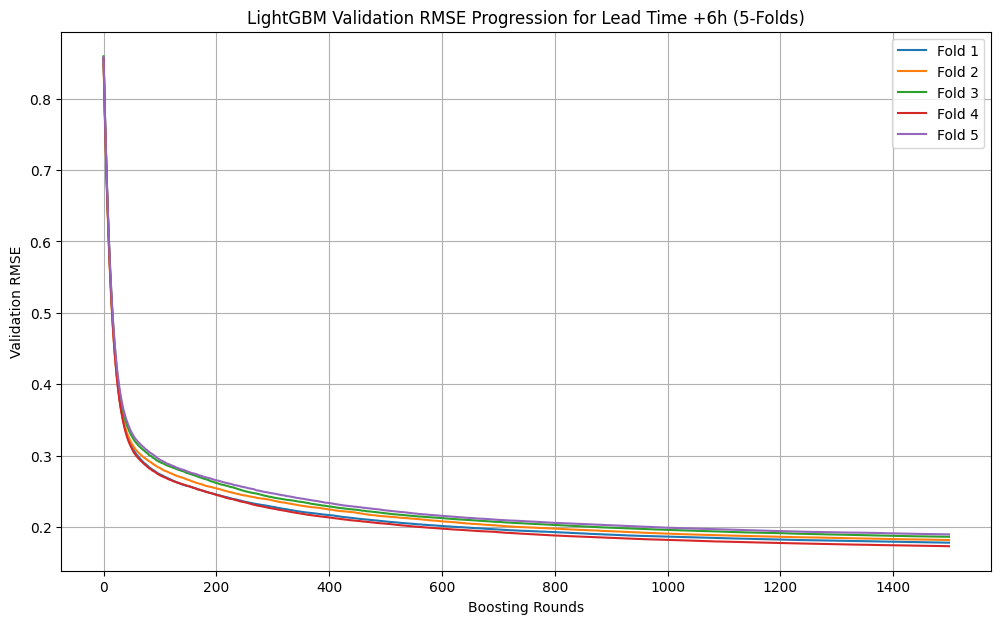

In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# 7.5. PLOT 5-FOLD TRAINING PROGRESS (RMSE over rounds)
# ============================================================

# Assuming eval_results_by_lead has been populated by the previous training cell (2542b734_exp05)

# Plotting RMSE progression for a representative lead time (e.g., +6h)
print("\nPlotting RMSE progression for Lead Time +6h across folds...")

lead_to_plot = 6 # Example: plot for +6h lead time

# Check if eval_results_by_lead has data for the lead_to_plot
if lead_to_plot in eval_results_by_lead and len(eval_results_by_lead[lead_to_plot]) > 0:
    plt.figure(figsize=(12, 7))
    for fold_idx, fold_eval_dict in enumerate(eval_results_by_lead[lead_to_plot]):
        # Access the validation set RMSE from the dictionary
        # The structure is typically {'valid_0': {'rmse': [...]} or {'validation': {'rmse': [...]}}
        # Using .get() for robustness
        if 'valid_0' in fold_eval_dict:
            rmse_scores = fold_eval_dict['valid_0']['rmse']
        elif 'validation' in fold_eval_dict:
            rmse_scores = fold_eval_dict['validation']['rmse']
        else:
            print(f"Warning: Could not find RMSE scores for fold {fold_idx+1} for lead time +{lead_to_plot}h.")
            continue

        plt.plot(rmse_scores, label=f'Fold {fold_idx+1}')

    plt.title(f'LightGBM Validation RMSE Progression for Lead Time +{lead_to_plot}h (5-Folds)')
    plt.xlabel('Boosting Rounds')
    plt.ylabel('Validation RMSE')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print(f"No evaluation results found for lead time +{lead_to_plot}h. Please ensure cell '2542b734_exp05' was run successfully.")


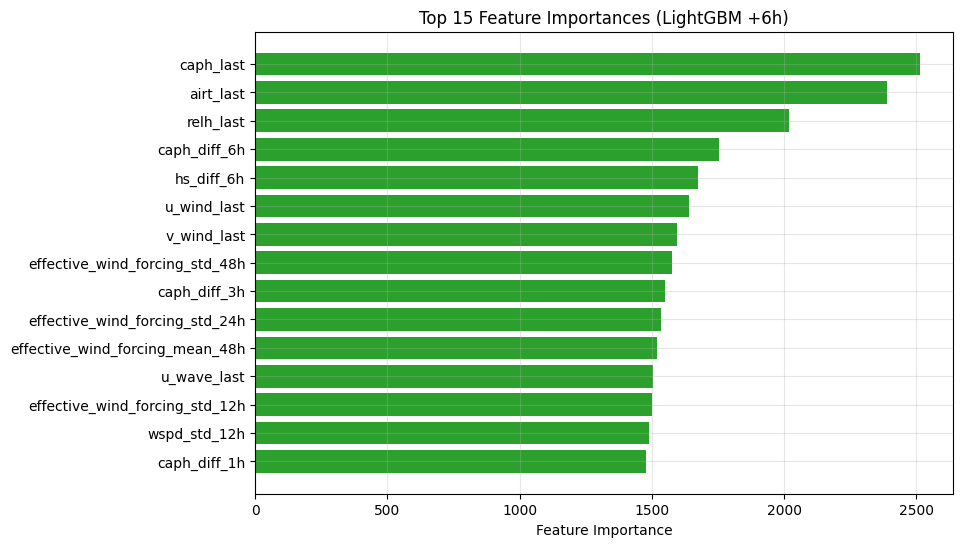

In [ ]:
# ============================================================
# 8. FEATURE IMPORTANCE PLOT
# ============================================================
import matplotlib.pyplot as plt

# +6h 모델 기준 피처 중요도
sample_model = models_by_lead[6][0]
imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": sample_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(imp_df["feature"].head(15)[::-1], imp_df["importance"].head(15)[::-1], color="#2ca02c")
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances (LightGBM +6h)")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# ============================================================
# 9. TEST INFERENCE & SUBMISSION CREATION
# ============================================================
print("\nRunning Test Inference on test_context.parquet...")
test_context = pd.read_parquet(TEST_CONTEXT_PATH)
test_index = pd.read_csv(TEST_INDEX_PATH)

# 테스트 데이터 기본 결측 방어 및 피처 생성
def process_test_case(group):
    g = group.sort_values("step_minute").copy()
    st = g["station"].iloc[0]

    num_cols = ["hs", "tp", "hmax", "wspd", "gust", "airt", "relh", "caph"]
    g[num_cols] = g[num_cols].interpolate(method="linear", limit_direction="both").ffill().bfill()
    g["wdir"] = g["wdir"].ffill().bfill() % 360.0
    g["wvdir"] = g["wvdir"].ffill().bfill() % 360.0
    g["hmax"] = np.maximum(g["hmax"], g["hs"])
    g["gust"] = np.maximum(g["gust"], g["wspd"])

    # 파랑 및 바람 벡터
    wdir_rad = np.deg2rad(g["wdir"])
    wvdir_rad = np.deg2rad(g["wvdir"])
    g["u_wind"] = g["wspd"] * np.sin(wdir_rad)
    g["v_wind"] = g["wspd"] * np.cos(wdir_rad)
    g["u_wave"] = g["hs"] * np.sin(wvdir_rad)
    g["v_wave"] = g["hs"] * np.cos(wvdir_rad)

    # 각도 차이 및 일치도
    diff = ((g["wdir"] - g["wvdir"] + 180) % 360) - 180
    g["wind_wave_diff"] = np.abs(diff)
    g["wind_wave_alignment"] = np.cos(np.deg2rad(diff))

    # 파랑 역학
    wl = 1.56 * (g["tp"] ** 2)
    g["wave_steepness"] = g["hs"] / np.maximum(wl, 1.0)
    g["wave_energy"] = g["hs"] ** 2
    g["effective_wind_forcing"] = (g["wspd"] ** 2) * g["wind_wave_alignment"]

    feats = extract_window_features(g)
    feats["station"] = st
    return feats

test_case_order = test_index["case_id"].drop_duplicates().tolist()
test_rows = []
for cid in test_case_order:
    grp = test_context[test_context["case_id"] == cid]
    test_rows.append(process_test_case(grp))

X_test_df = pd.DataFrame(test_rows)
X_test_df = pd.get_dummies(X_test_df, columns=["station"], drop_first=False)

# 훈련 셋 컬럼과 일치화
for col in feature_cols:
    if col not in X_test_df.columns:
        X_test_df[col] = 0
X_test_df = X_test_df[feature_cols]

# 5-Fold 앙상블 추론
test_preds_by_lead = {}
for lead_idx, lead_h in enumerate(LEAD_HOURS):
    fold_models = models_by_lead[lead_h]
    preds_folds = [m.predict(X_test_df) for m in fold_models]
    test_preds_by_lead[lead_h] = np.mean(preds_folds, axis=0)

# 제출 형식 변환
sub_rows = []
for i, cid in enumerate(test_case_order):
    for lead_h in LEAD_HOURS:
        val = float(test_preds_by_lead[lead_h][i])
        sub_rows.append({"case_id": cid, "lead_h": lead_h, "hs_pred": val})

submission = test_index.merge(pd.DataFrame(sub_rows), on=["case_id", "lead_h"], how="left")
submission["hs_pred"] = submission["hs_pred"].clip(lower=0.0, upper=30.0)
submission.to_csv(SUBMISSION_PATH, index=False, encoding="utf-8")

print("=" * 80)
print(f"EXP05 SUBMISSION SAVED: {SUBMISSION_PATH}")
print("=" * 80)
print("\nPrediction Stats:")
display(submission["hs_pred"].describe())
display(submission.head(12))



Running Test Inference on test_context.parquet...
EXP05 SUBMISSION SAVED: submission_exp05.csv

Prediction Stats:


,hs_pred
count,1200.000000
mean,1.563475
std,0.495371
min,0.272964
25%,1.209433
50%,1.534114
75%,1.842815
max,4.059013


,case_id,station,lead_h,hs_pred
0,C0001,S-ORS,3,2.541827
1,C0001,S-ORS,6,1.436953
2,C0001,S-ORS,9,1.319137
3,C0001,S-ORS,12,1.590410
4,C0001,S-ORS,18,0.872041
5,C0001,S-ORS,24,1.169465
6,C0002,I-ORS,3,1.601117
7,C0002,I-ORS,6,1.569982
8,C0002,I-ORS,9,1.605004
9,C0002,I-ORS,12,1.506192
